Nadaraya-Watson核

In [12]:
import torch
from torch import nn
from d2l import torch as d2l

In [13]:
#@save
def show_heatmaps(matrices, xlabel, ylabel, titles=None, figsize=(2.5, 2.5),
                  cmap='Reds'):
    """显示矩阵热图"""
    d2l.use_svg_display()
    num_rows, num_cols = matrices.shape[0], matrices.shape[1]
    fig, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize,
                                 sharex=True, sharey=True, squeeze=False)
    for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
        for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)):
            pcm = ax.imshow(matrix.detach().numpy(), cmap=cmap)
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(ylabel)
            if titles:
                ax.set_title(titles[j])
    fig.colorbar(pcm, ax=axes, shrink=0.6);

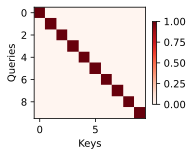

In [14]:
attention_weights = torch.eye(10).reshape((1, 1, 10, 10))
show_heatmaps(attention_weights, xlabel='Keys', ylabel='Queries')

In [15]:
print("attention_weights", attention_weights)

attention_weights tensor([[[[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]]]])


真实规律是 f(x)。x_train 是采样点，y_train = f(x_train) + 噪声 是对真实规律的带噪观测。y_truth = f(x_test) 是测试点上的无噪真值。目标是用 (x_train, y_train) 通过注意力池化（核回归）对 x_test 做预测，使预测值 y_hat 尽量接近 y_truth，从而验证模型学到了真实规律 f 而非过拟合噪声。

In [16]:
n_train = 50  # 训练样本数
x_train, _ = torch.sort(torch.rand(n_train) * 5)   # 排序后的训练样本。 torch.rand返回(0,1]之间的随机数

def f(x):
    return 2 * torch.sin(x) + x**0.8

y_train = f(x_train) + torch.normal(0.0, 0.5, (n_train,))  # 训练样本的输出
x_test = torch.arange(0, 5, 0.1)  # 测试样本
y_truth = f(x_test)  # 测试样本的真实输出
n_test = len(x_test)  # 测试样本数
# n_test

In [17]:
def plot_kernel_reg(y_hat):
    d2l.plot(x_test, [y_truth, y_hat], 'x', 'y', legend=['Truth', 'Pred'],
             xlim=[0, 5], ylim=[-1, 5])
    d2l.plt.plot(x_train, y_train, 'o', alpha=0.5);

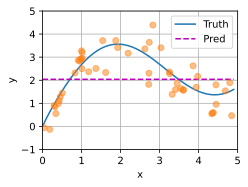

In [18]:
y_hat = torch.repeat_interleave(y_train.mean(), n_test)
plot_kernel_reg(y_hat)

注意力的本质是判断目标对其他对象的注意力程度，或者反之目标受其他对象的影响程度
令 $w_{ik} = \frac{\alpha(x_i, x_k)}{\sum_{j=1}^{n} \alpha(x_i, x_j)} $,表示$x_k$对$x_i$的影响是整体影响的多少分之一
则 $\hat{y}_i = \sum_{j=1}^{n} w_{ij} \cdot y_j$ ，表示$\hat{y}_i$根据$x_i$收到$x_k$的影响来使用各种$y_k$合成的值应该是多少

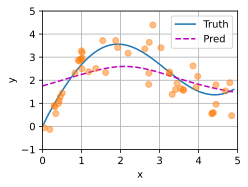

In [19]:

def alpha(a_x_train, a_x_test):
    scores = -(a_x_train - a_x_test)**2/2
    return torch.exp(scores)


y_preds = []

for a_x_test in x_test:
    y_pred = 0
    scores = []

    for a_x_train in x_train:
        score = alpha(a_x_train, a_x_test)
        scores.append(score)
    score_sum = sum(scores)

    y_pred = 0
    for score, a_y_train in zip(scores, y_train):
        y_pred += score/score_sum*a_y_train
    y_preds.append(y_pred)

plot_kernel_reg(y_preds)



X_repeat: torch.Size([50, 50])
x_train: torch.Size([50])
diff: torch.Size([50, 50])
attention_weights: torch.Size([50, 50])
y_preds: tensor([1.7557, 1.8038, 1.8525, 1.9018, 1.9516, 2.0017, 2.0521, 2.1026, 2.1530,
        2.2031, 2.2525, 2.3009, 2.3478, 2.3928, 2.4352, 2.4743, 2.5093, 2.5396,
        2.5642, 2.5826, 2.5939, 2.5979, 2.5942, 2.5829, 2.5641, 2.5383, 2.5062,
        2.4686, 2.4263, 2.3802, 2.3313, 2.2804, 2.2282, 2.1753, 2.1223, 2.0697,
        2.0178, 1.9670, 1.9175, 1.8695, 1.8232, 1.7786, 1.7359, 1.6951, 1.6563,
        1.6194, 1.5846, 1.5517, 1.5208, 1.4919])


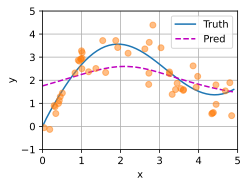

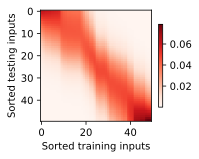

In [20]:
# X_repeat的形状:(n_test,n_train),
# 每一行都包含着相同的测试输入（例如：同样的查询）
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))
print("X_repeat:",X_repeat.shape)
print("x_train:",x_train.shape)
diff = -(X_repeat - x_train)**2 / 2
print("diff:",diff.shape)
# print(diff)
attention_weights = nn.functional.softmax(input=diff, dim=1)
print("attention_weights:",attention_weights.shape)
# 注意矩阵相乘的顺序， attention的dim1表示 每个train对当前test对影响，attention_weights*y_train就表示当前x_test收到的加权影响
# y_train*attention_weights则完全不对
y_preds = torch.matmul(attention_weights, y_train) 
print("y_preds:",y_preds)
plot_kernel_reg(y_preds)
d2l.show_heatmaps(attention_weights.unsqueeze(0).unsqueeze(0),
                  xlabel='Sorted training inputs', ylabel='Sorted testing inputs')

将Nadaraya-Watson核改成带参数，所谓带参数就是指这个参数可以被训练

In [21]:
from turtle import forward


class NWKernelRegression(nn.Module):
    def __init__(self, **kwargs) -> None:
        super().__init__( **kwargs)
        self.w = nn.Parameter(torch.rand((1,), requires_grad=True))

    # queries 是所有 x_trian 元素。 shape(x_train.size)
    # keys 要为 x_train做准备，每一个 x_train 元素都有自己的 keys，这些keys是除了这个 x_train 元素以外的其他 x_train
    # keys.shape = (x_train.size, x_train.size -1)
    # values 是 keys 中，每一个 x_train 对应的 y_train
    # values.shape = (x_train.size, x_train.size -1)
    def forward(self, queries, keys, values):
        print("queries",queries.shape)
        print("keys",keys.shape)

        queries = queries.reshape(-1, 1)
        diff = -((queries - keys)*self.w)**2 / 2
        # diff.shape (x_train.size, x_train.size -1)
        self.attention_weights = nn.functional.softmax(input=diff, dim=1)
        print("attention_weights",self.attention_weights.shape)
        y_preds = (self.attention_weights * values).sum(dim=1) 
        # print("y_preds",y_preds)
        return y_preds
        ...


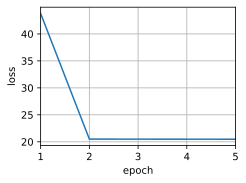

In [22]:
# 准备好训练数据
X_tile = x_train.repeat(n_train, 1)
Y_tile = y_train.repeat(n_train, 1)
print("X_tile:", X_tile.shape)
print("Y_tile:", Y_tile.shape)

keys = X_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape(n_train, -1)
values = Y_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape(n_train, -1)
print("keys:", keys.shape)
print("values:", values.shape)
# 训练
net = NWKernelRegression()
loss = nn.MSELoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=0.5)
animator = d2l.Animator(xlabel='epoch', ylabel='loss', xlim=[1, 5])

for epoch in range(5):
    trainer.zero_grad()
    l = loss(net(x_train, keys, values), y_train)
    l.sum().backward()
    trainer.step()
    print(f'epoch {epoch + 1}, loss {float(l.sum()):.6f}')
    animator.add(epoch + 1, float(l.sum()))




queries torch.Size([50])
keys torch.Size([50, 50])
attention_weights torch.Size([50, 50])


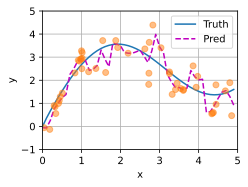

In [23]:
# keys的形状:(n_test，n_train)，每一行包含着相同的训练输入（例如，相同的键）
keys = x_train.repeat((n_test, 1))
# value的形状:(n_test，n_train)
values = y_train.repeat((n_test, 1))
y_hat = net(x_test, keys, values).unsqueeze(1).detach()
plot_kernel_reg(y_hat)

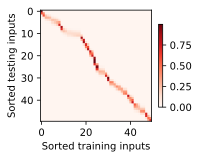

In [24]:
d2l.show_heatmaps(net.attention_weights.unsqueeze(0).unsqueeze(0),
                  xlabel='Sorted training inputs',
                  ylabel='Sorted testing inputs')